# Experiment 9 - Scenario 1

**Name:** SaiSanjay R  
**Roll No:** 24BAD102



### 1. IMPORT LIBRARIES



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error



### 2. LOAD DATASET (MovieLens)



In [2]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

Ratings Shape: (85271, 4)
Movies Shape: (9742, 3)



### 3. DATA INSPECTION & PREPROCESSING

In [3]:
print("\n--- Ratings Info ---")
print(ratings.info())

print("\n--- Missing Values ---")
print(ratings.isnull().sum())

print("\n--- Sample Data ---")
print(ratings.head())


--- Ratings Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85271 entries, 0 to 85270
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     85271 non-null  int64  
 1   movieId    85271 non-null  int64  
 2   rating     85270 non-null  float64
 3   timestamp  85270 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 2.6 MB
None

--- Missing Values ---
userId       0
movieId      0
rating       1
timestamp    1
dtype: int64

--- Sample Data ---
   userId  movieId  rating    timestamp
0       1        1     4.0  964982703.0
1       1        3     4.0  964981247.0
2       1        6     4.0  964982224.0
3       1       47     5.0  964983815.0
4       1       50     5.0  964982931.0



### 4. CREATE USER-ITEM MATRIX



In [4]:
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("\nUser-Item Matrix Shape:", user_item_matrix.shape)


User-Item Matrix Shape: (554, 8757)



### 5. HANDLE MISSING VALUES




In [5]:
user_item_filled = user_item_matrix.fillna(0)


### 6. COMPUTE SIMILARITY (COSINE)



In [6]:
user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

print("\nUser Similarity Matrix Shape:", user_similarity_df.shape)


User Similarity Matrix Shape: (554, 554)



### 7. FIND TOP-N SIMILAR USERS



In [7]:
def get_similar_users(user_id, n=5):
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    sim_users = sim_scores.iloc[1:n+1]  # skip itself
    return sim_users

print("\nTop similar users for User 1:")
print(get_similar_users(1))


Top similar users for User 1:
userId
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64



### 8. PREDICT RATINGS FOR UNSEEN MOVIES


In [8]:
def predict_ratings(user_id, n_neighbors=5):
    similar_users = get_similar_users(user_id, n_neighbors)

    user_ratings = user_item_filled.loc[user_id]

    predicted_ratings = {}

    for movie in user_item_filled.columns:
        if user_ratings[movie] == 0:  # unseen movie
            weighted_sum = 0
            similarity_sum = 0

            for sim_user, sim_score in similar_users.items():
                rating = user_item_filled.loc[sim_user, movie]
                if rating > 0:
                    weighted_sum += sim_score * rating
                    similarity_sum += sim_score

            if similarity_sum > 0:
                predicted_ratings[movie] = weighted_sum / similarity_sum

    return predicted_ratings

### 9. TOP-N RECOMMENDATIONS


In [9]:
def recommend_movies(user_id, n=5):
    preds = predict_ratings(user_id)

    sorted_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)

    top_movies = sorted_preds[:n]

    movie_ids = [movie[0] for movie in top_movies]

    return movies[movies['movieId'].isin(movie_ids)]

print("\nRecommended Movies for User 1:")
print(recommend_movies(1, 5))


Recommended Movies for User 1:
     movieId                                              title  \
449      514                                    Ref, The (1994)   
474      541                                Blade Runner (1982)   
585      720  Wallace & Gromit: The Best of Aardman Animatio...   
602      750  Dr. Strangelove or: How I Learned to Stop Worr...   
659      858                              Godfather, The (1972)   

                         genres  
449                      Comedy  
474      Action|Sci-Fi|Thriller  
585  Adventure|Animation|Comedy  
602                  Comedy|War  
659                 Crime|Drama  


### FAST EVALUATION (OPTIMIZED)


In [10]:

def fast_evaluate(sample_size=500):

    sample_data = ratings.sample(sample_size, random_state=42)

    actual = []
    predicted = []

    for _, row in sample_data.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']

        similar_users = get_similar_users(user, 5)

        weighted_sum = 0
        similarity_sum = 0

        for sim_user, sim_score in similar_users.items():
            rating = user_item_filled.loc[sim_user, movie]

            if rating > 0:
                weighted_sum += sim_score * rating
                similarity_sum += sim_score

        if similarity_sum > 0:
            pred = weighted_sum / similarity_sum

            actual.append(true_rating)
            predicted.append(pred)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    print("\nFast Evaluation Results:")
    print("RMSE:", rmse)
    print("MAE:", mae)

fast_evaluate()


Fast Evaluation Results:
RMSE: 1.0701692151809041
MAE: 0.8131787393173198


### ANALYSIS TASKS


In [11]:

total_elements = user_item_matrix.size
non_zero = np.count_nonzero(user_item_matrix)

sparsity = 1 - (non_zero / total_elements)

print("\nSparsity of User-Item Matrix:", sparsity)


Sparsity of User-Item Matrix: 0.0


### VISUALIZATION
### 1. HEATMAP (User-Item Matrix - small sample)
### 2. USER SIMILARITY HEATMAP
### 3. TOP RECOMMENDATIONS VISUALIZATION


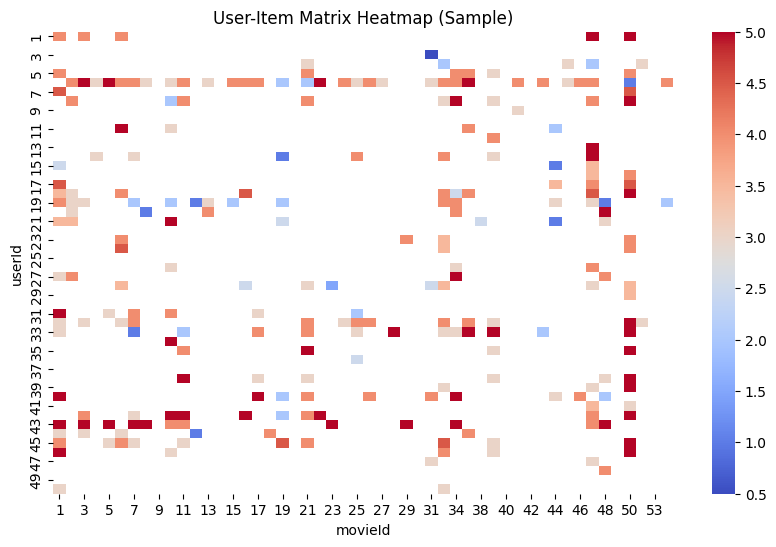

In [13]:

plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix.iloc[:50, :50], cmap='coolwarm')
plt.title("User-Item Matrix Heatmap (Sample)")
plt.show()


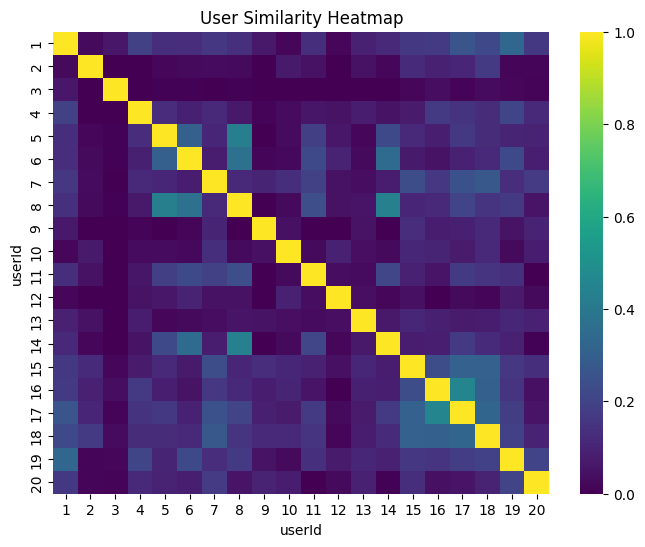

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("User Similarity Heatmap")
plt.show()

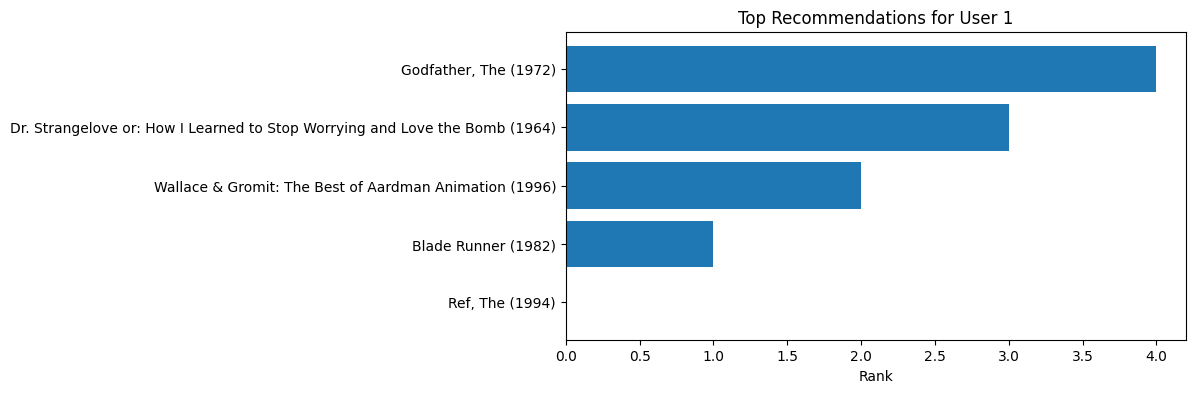

In [15]:

def plot_recommendations(user_id):
    recs = recommend_movies(user_id, 5)

    plt.figure(figsize=(8,4))
    plt.barh(recs['title'], range(len(recs)))
    plt.title(f"Top Recommendations for User {user_id}")
    plt.xlabel("Rank")
    plt.show()

plot_recommendations(1)